In [1]:
import pandas as pd
from src.api import get_league_data
from src.config import config

# Load config
LEAGUE_ID = config.league_id
YEARS = config.years
cookies = config.cookies
headers = config.headers

all_scores_data = []

for year in YEARS:
    # Map teamId -> {owner_id, team_name} for the current year
    team_map = {}
    
    # Iterate through weeks (Standard fantasy season is usually up to 17 or 18 weeks)
    for week in range(1, 19):
        data = get_league_data(
            league_id=LEAGUE_ID, 
            year=year, 
            scoring_period=week, 
            cookies=cookies, 
            headers=headers,
            cache_only=True  # Use cache-only mode to avoid API calls
        )
        
        if not data:
            continue

        # 1. Build Team Metadata Map if 'teams' data is present
        # We update this every week in case names change, though usually they are static per year
        if "teams" in data:
            for team in data["teams"]:
                t_id = team["id"]
                
                # --- Owner ID Logic ---
                owner_id = team.get("primaryOwner")
                if not owner_id and "owners" in team and team["owners"]:
                     owner_id = team["owners"][0]
                if not owner_id:
                    owner_id = t_id 
                
                # --- Team Name Logic (mirroring processing.py) ---
                # Try location + nickname first
                loc = team.get("location", "")
                nick = team.get("nickname", "")
                # Some years/leagues might have empty strings for location
                if loc or nick:
                    team_name = f"{loc} {nick}".strip()
                else:
                    # Fallback to 'name' or 'abbrev'
                    team_name = team.get("name", team.get("abbrev", f"Team {t_id}"))
                
                team_map[t_id] = {
                    "owner_id": owner_id,
                    "team_name": team_name
                }

        # 2. Extract scores from the schedule
        schedule = data.get("schedule", [])
        for match in schedule:
            # Filter for the specific week we are processing
            if match.get("matchupPeriodId") != week:
                continue
            
            # Process both 'home' and 'away' sides
            for side in ["home", "away"]:
                side_data = match.get(side)
                
                if side_data and "teamId" in side_data:
                    team_id = side_data["teamId"]
                    points = side_data.get("totalPoints", 0)
                    
                    # Resolve metadata using our map
                    meta = team_map.get(team_id, {})
                    owner_id = meta.get("owner_id", team_id)
                    team_name = meta.get("team_name", f"Team {team_id}")
                    
                    all_scores_data.append({
                        "owner_id": owner_id,
                        "year": year,
                        "week": week,
                        "score": points,
                        "team_name": team_name
                    })

# Create the final DataFrame
df_history = pd.DataFrame(all_scores_data)

# Display results
print(f"Generated {len(df_history)} rows.")
print(df_history.head())

Cache-only mode enabled, but no cache entry found. Skipping 1283828, 2025, 16, ['mMatchup', 'mTeam'].
Cache-only mode enabled, but no cache entry found. Skipping 1283828, 2025, 17, ['mMatchup', 'mTeam'].
Cache-only mode enabled, but no cache entry found. Skipping 1283828, 2025, 18, ['mMatchup', 'mTeam'].
Cache-only mode enabled, but no cache entry found. Skipping 1283828, 2024, 18, ['mMatchup', 'mTeam'].
Cache-only mode enabled, but no cache entry found. Skipping 1283828, 2023, 18, ['mMatchup', 'mTeam'].
Cache-only mode enabled, but no cache entry found. Skipping 1283828, 2022, 18, ['mMatchup', 'mTeam'].
Cache-only mode enabled, but no cache entry found. Skipping 1283828, 2021, 18, ['mMatchup', 'mTeam'].
Cache-only mode enabled, but no cache entry found. Skipping 1283828, 2020, 17, ['mMatchup', 'mTeam'].
Cache-only mode enabled, but no cache entry found. Skipping 1283828, 2020, 18, ['mMatchup', 'mTeam'].
Cache-only mode enabled, but no cache entry found. Skipping 1283828, 2019, 17, ['m

Generated 1572 rows.
                                 owner_id  year  week  score  \
0  {26F6928C-CAA4-4D39-BFBE-6E0E1B115BDE}  2025     1   77.8   
1  {1AA340FF-A390-4F35-AE78-42C03AE086EF}  2025     1   80.4   
2  {08EB9138-9E0E-4A98-87B3-90D81641A473}  2025     1  107.1   
3  {5CCFFF4C-122C-458C-86DF-CC2EEA75669A}  2025     1   93.3   
4  {3804D96D-87A8-4622-8272-372AB476B89A}  2025     1   98.5   

                      team_name  
0            Brockback Mountain  
1          Gibbs Me That Trophy  
2              Saquon Deez Nuts  
3           Butker's Housewives  
4  Arthur Blank's Ring of Honor  


In [2]:
# Sort by score descending (highest scores first)
df_history = df_history.sort_values(by="score", ascending=False)
df_history

,owner_id,year,week,score,team_name
1074,{27359244-DD5F-44EF-B592-44DD5FC4EF84},2020,7,199.6,Duke Nuk'em
438,{AE0910AB-A77E-4B81-8910-ABA77E9B817E},2023,5,194.0,The ESPN Autodrafts
1061,{1AA340FF-A390-4F35-AE78-42C03AE086EF},2020,6,182.3,Julio! Get the Stretch
844,{27359244-DD5F-44EF-B592-44DD5FC4EF84},2021,5,182.1,AnaL me chr1s
555,{39196D9B-423C-4F89-9DF8-9460D73643D1},2023,15,174.9,Blandford Recreation Centre
...,...,...,...,...,...
167,{26F6928C-CAA4-4D39-BFBE-6E0E1B115BDE},2025,14,0.0,Brockback Mountain
164,{759299A2-E642-40CA-9299-A2E642C0CA4B},2025,14,0.0,Micro Penix Jr
163,{08EB9138-9E0E-4A98-87B3-90D81641A473},2025,14,0.0,Saquon Deez Nuts
162,{39196D9B-423C-4F89-9DF8-9460D73643D1},2025,14,0.0,The Storm of the Century


In [3]:
# Fetch the most recent year's data to get the member list
recent_year = max(YEARS)
# We just need one week's data to get the 'members' list
recent_data = get_league_data(
    league_id=LEAGUE_ID, 
    year=recent_year, 
    scoring_period=1, 
    cookies=cookies, 
    headers=headers,
    cache_only=True
)

if recent_data and "members" in recent_data:
    # Create a mapping of owner_id -> owner_name
    members = recent_data["members"]
    owner_map = {}
    for m in members:
        # specific logic to get a readable name
        name = m.get("lastName", m.get("firstName", "Unknown"))
        owner_map[m["id"]] = name
        
    # Map the owner_id in df_history to the new owner_name column
    df_history["owner_name"] = df_history["owner_id"].map(owner_map)
    
    # Fill NaN values
    df_history["owner_name"] = df_history["owner_name"].fillna("Unknown")
    
    print("Added 'owner_name' column.")
    print(df_history[["year", "week", "team_name", "owner_name", "score"]].head())
else:
    print("Could not fetch member data.")

Added 'owner_name' column.
      year  week                    team_name owner_name  score
1074  2020     7                  Duke Nuk'em     LeFeve  199.6
438   2023     5          The ESPN Autodrafts       Matz  194.0
1061  2020     6       Julio! Get the Stretch   McDaniel  182.3
844   2021     5                AnaL me chr1s     LeFeve  182.1
555   2023    15  Blandford Recreation Centre    Trandel  174.9


In [4]:
df_history

,owner_id,year,week,score,team_name,owner_name
1074,{27359244-DD5F-44EF-B592-44DD5FC4EF84},2020,7,199.6,Duke Nuk'em,LeFeve
438,{AE0910AB-A77E-4B81-8910-ABA77E9B817E},2023,5,194.0,The ESPN Autodrafts,Matz
1061,{1AA340FF-A390-4F35-AE78-42C03AE086EF},2020,6,182.3,Julio! Get the Stretch,McDaniel
844,{27359244-DD5F-44EF-B592-44DD5FC4EF84},2021,5,182.1,AnaL me chr1s,LeFeve
555,{39196D9B-423C-4F89-9DF8-9460D73643D1},2023,15,174.9,Blandford Recreation Centre,Trandel
...,...,...,...,...,...,...
167,{26F6928C-CAA4-4D39-BFBE-6E0E1B115BDE},2025,14,0.0,Brockback Mountain,Gantt
164,{759299A2-E642-40CA-9299-A2E642C0CA4B},2025,14,0.0,Micro Penix Jr,Ferrara
163,{08EB9138-9E0E-4A98-87B3-90D81641A473},2025,14,0.0,Saquon Deez Nuts,Froneberger
162,{39196D9B-423C-4F89-9DF8-9460D73643D1},2025,14,0.0,The Storm of the Century,Trandel


In [5]:
# Get the top score for each unique owner
# We group by 'owner_name' and find the index of the maximum 'score'
top_scores_indices = df_history.groupby("owner_name")["score"].idxmax()
df_top_scores = df_history.loc[top_scores_indices]

# Sort by score descending to see who has the highest "best score"
df_top_scores = df_top_scores.sort_values(by="score", ascending=False).reset_index(drop=True)

print(f"Resulting dataframe has {len(df_top_scores)} rows.")
df_top_scores

Resulting dataframe has 13 rows.


,owner_id,year,week,score,team_name,owner_name
0,{27359244-DD5F-44EF-B592-44DD5FC4EF84},2020,7,199.6,Duke Nuk'em,LeFeve
1,{AE0910AB-A77E-4B81-8910-ABA77E9B817E},2023,5,194.0,The ESPN Autodrafts,Matz
2,{1AA340FF-A390-4F35-AE78-42C03AE086EF},2020,6,182.3,Julio! Get the Stretch,McDaniel
3,{39196D9B-423C-4F89-9DF8-9460D73643D1},2023,15,174.9,Blandford Recreation Centre,Trandel
4,{AA636B9F-04C1-41B8-A36B-9F04C1B1B886},2021,14,173.9,"Qlio, Qook and the Os",Grogan
5,{08EB9138-9E0E-4A98-87B3-90D81641A473},2024,10,173.5,Chasing the Kupp,Froneberger
6,{1033B66D-BBAD-4054-B3B6-6DBBAD405448},2019,1,172.6,We are Cookin’,Randall
7,{5CCFFF4C-122C-458C-86DF-CC2EEA75669A},2018,4,171.9,Mike Thomas The Tank Engine,Roberts
8,{759299A2-E642-40CA-9299-A2E642C0CA4B},2024,1,168.3,Micro Penix Jr,Ferrara
9,{750B0E67-B47B-4C11-8B0E-67B47BFC1160},2018,8,167.5,Superbowl Hangover,Cooper


In [6]:
# Manual Data Corrections

# Replace 'Unknown' owner name with 'Ashby'
df_top_scores["owner_name"] = df_top_scores["owner_name"].replace("Unknown", "Ashby")

# Update Ferrara's record manually
ferrara_idx = df_top_scores[df_top_scores["owner_name"] == "Ferrara"].index
if not ferrara_idx.empty:
    df_top_scores.loc[ferrara_idx, "year"] = 2025
    df_top_scores.loc[ferrara_idx, "week"] = 15
    df_top_scores.loc[ferrara_idx, "score"] = 185.1

# Re-sort the dataframe by score descending
df_top_scores = df_top_scores.sort_values(by="score", ascending=False).reset_index(drop=True)

# Display the updated dataframe
df_top_scores

,owner_id,year,week,score,team_name,owner_name
0,{27359244-DD5F-44EF-B592-44DD5FC4EF84},2020,7,199.6,Duke Nuk'em,LeFeve
1,{AE0910AB-A77E-4B81-8910-ABA77E9B817E},2023,5,194.0,The ESPN Autodrafts,Matz
2,{759299A2-E642-40CA-9299-A2E642C0CA4B},2025,15,185.1,Micro Penix Jr,Ferrara
3,{1AA340FF-A390-4F35-AE78-42C03AE086EF},2020,6,182.3,Julio! Get the Stretch,McDaniel
4,{39196D9B-423C-4F89-9DF8-9460D73643D1},2023,15,174.9,Blandford Recreation Centre,Trandel
5,{AA636B9F-04C1-41B8-A36B-9F04C1B1B886},2021,14,173.9,"Qlio, Qook and the Os",Grogan
6,{08EB9138-9E0E-4A98-87B3-90D81641A473},2024,10,173.5,Chasing the Kupp,Froneberger
7,{1033B66D-BBAD-4054-B3B6-6DBBAD405448},2019,1,172.6,We are Cookin’,Randall
8,{5CCFFF4C-122C-458C-86DF-CC2EEA75669A},2018,4,171.9,Mike Thomas The Tank Engine,Roberts
9,{750B0E67-B47B-4C11-8B0E-67B47BFC1160},2018,8,167.5,Superbowl Hangover,Cooper


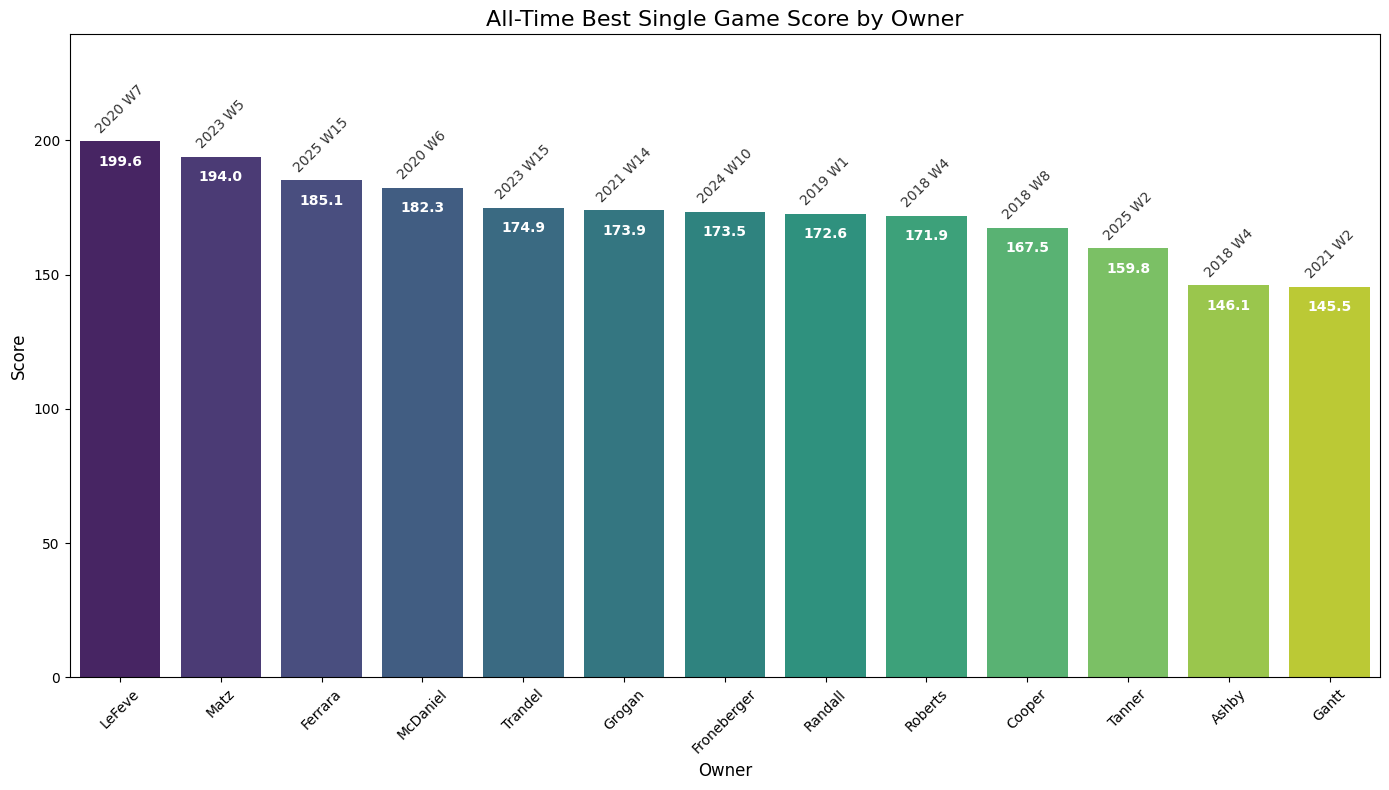

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure matplotlib is inline
%matplotlib inline

plt.figure(figsize=(14, 8))

# Create barplot
# hue="owner_name" and legend=False are used to avoid FutureWarning in recent seaborn versions
ax = sns.barplot(
    data=df_top_scores,
    x="owner_name",
    y="score",
    hue="owner_name",
    palette="viridis",
    legend=False
)

# Add annotations
for i, row in df_top_scores.iterrows():
    # Text label: Year and Week
    label_text = f"{int(row['year'])} W{int(row['week'])}"
    
    # Position text above the bar
    ax.text(
        i, 
        row["score"] + 2, 
        label_text, 
        ha="center", 
        va="bottom", 
        rotation=45, 
        fontsize=10,
        color="#333333"
    )
    
    # Add the score value inside the bar for clarity
    ax.text(
        i,
        row["score"] - 5,
        f"{row['score']:.1f}",
        ha="center",
        va="top",
        color="white",
        fontweight="bold"
    )

plt.title("All-Time Best Single Game Score by Owner", fontsize=16)
plt.xlabel("Owner", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, df_top_scores["score"].max() * 1.2) # Extend y-axis to fit annotations
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()